# A/B Testing & Uplift Modeling — Hillstrom E-Mail Marketing Dataset
**Phase 1: Data Loading, EDA, Metric Definitions, and Statistical Assumption Checks**

---
## Section 1 — Data Loading & EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style='whitegrid')
%matplotlib inline

# Load data
df = pd.read_csv('../data/hillstrom.csv')

print('=== Dataset Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== First 5 Rows ===')
df.head()

=== Dataset Shape ===
(64000, 12)

=== Data Types ===
recency              int64
history_segment     object
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
segment             object
visit                int64
conversion           int64
spend              float64
dtype: object

=== First 5 Rows ===


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [2]:
print('=== Null Counts ===')
print(df.isnull().sum())
print(f'\nTotal nulls: {df.isnull().sum().sum()}')

=== Null Counts ===
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

Total nulls: 0


In [3]:
print('=== Value Counts: segment (Treatment Column) ===')
print(df['segment'].value_counts())
print()
print(df['segment'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

=== Value Counts: segment (Treatment Column) ===
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

segment
Womens E-Mail    33.42%
Mens E-Mail      33.29%
No E-Mail        33.29%
Name: proportion, dtype: object


In [4]:
# Create binary treatment column: 0 = control (No E-Mail), 1 = treatment (any e-mail)
df['treatment'] = (df['segment'] != 'No E-Mail').astype(int)

print('=== Group Sizes: Treatment vs Control ===')
group_sizes = df['treatment'].value_counts().sort_index()
print(f'Control   (treatment=0): {group_sizes[0]:,}')
print(f'Treatment (treatment=1): {group_sizes[1]:,}')
print(f'Total: {len(df):,}')

=== Group Sizes: Treatment vs Control ===
Control   (treatment=0): 21,306
Treatment (treatment=1): 42,694
Total: 64,000


---
## Section 2 — Metric Definition

In [5]:
# Primary metric: conversion rate
# Guardrail metric: visit rate

control = df[df['treatment'] == 0]
treatment = df[df['treatment'] == 1]

control_conversion   = control['conversion'].mean()
treatment_conversion = treatment['conversion'].mean()

control_visit   = control['visit'].mean()
treatment_visit = treatment['visit'].mean()

print('=== PRIMARY METRIC: Conversion Rate ===')
print(f'  Control   conversion rate: {control_conversion:.4f} ({control_conversion*100:.2f}%)')
print(f'  Treatment conversion rate: {treatment_conversion:.4f} ({treatment_conversion*100:.2f}%)')
print(f'  Absolute lift: {(treatment_conversion - control_conversion)*100:+.2f} pp')

print()
print('=== GUARDRAIL METRIC: Visit Rate ===')
print(f'  Control   visit rate: {control_visit:.4f} ({control_visit*100:.2f}%)')
print(f'  Treatment visit rate: {treatment_visit:.4f} ({treatment_visit*100:.2f}%)')
print(f'  Absolute lift: {(treatment_visit - control_visit)*100:+.2f} pp')

=== PRIMARY METRIC: Conversion Rate ===
  Control   conversion rate: 0.0057 (0.57%)
  Treatment conversion rate: 0.0107 (1.07%)
  Absolute lift: +0.50 pp

=== GUARDRAIL METRIC: Visit Rate ===
  Control   visit rate: 0.1062 (10.62%)
  Treatment visit rate: 0.1670 (16.70%)
  Absolute lift: +6.09 pp


---
## Section 3 — Statistical Assumption Checks

In [6]:
# --- Check 1: Group Balance ---
n_control   = group_sizes[0]
n_treatment = group_sizes[1]
ratio = n_control / n_treatment

print('=== CHECK 1: Group Balance ===')
print(f'  Control   n = {n_control:,}')
print(f'  Treatment n = {n_treatment:,}')
print(f'  Ratio (control / treatment) = {ratio:.4f}')

balance_pass = 0.9 <= ratio <= 1.1
print(f'  Result: {"PASS" if balance_pass else "FAIL"} (target ratio 0.90 – 1.10)')

=== CHECK 1: Group Balance ===
  Control   n = 21,306
  Treatment n = 42,694
  Ratio (control / treatment) = 0.4990
  Result: FAIL (target ratio 0.90 – 1.10)


In [7]:
# --- Check 2: Sample Ratio Mismatch (SRM) ---
# Under the null, we expect equal group sizes.
# Use a chi-square goodness-of-fit test on observed vs expected counts.

from scipy.stats import chisquare

total = n_control + n_treatment
expected = total / 2  # equal split expectation

chi2_stat, srm_pvalue = chisquare([n_control, n_treatment], f_exp=[expected, expected])

srm_detected = srm_pvalue < 0.05

print('=== CHECK 2: Sample Ratio Mismatch (SRM) ===')
print(f'  Chi-square statistic: {chi2_stat:.4f}')
print(f'  p-value: {srm_pvalue:.4f}')
print(f'  SRM detected: {srm_detected}')
srm_pass = not srm_detected
print(f'  Result: {"PASS" if srm_pass else "FAIL"} (SRM present if p < 0.05)')

=== CHECK 2: Sample Ratio Mismatch (SRM) ===
  Chi-square statistic: 7147.6022
  p-value: 0.0000
  SRM detected: True
  Result: FAIL (SRM present if p < 0.05)


C:\Users\Sai Spandana\AppData\Local\Temp\ipykernel_12764\3804904983.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Group', y='history', ax=axes[1],


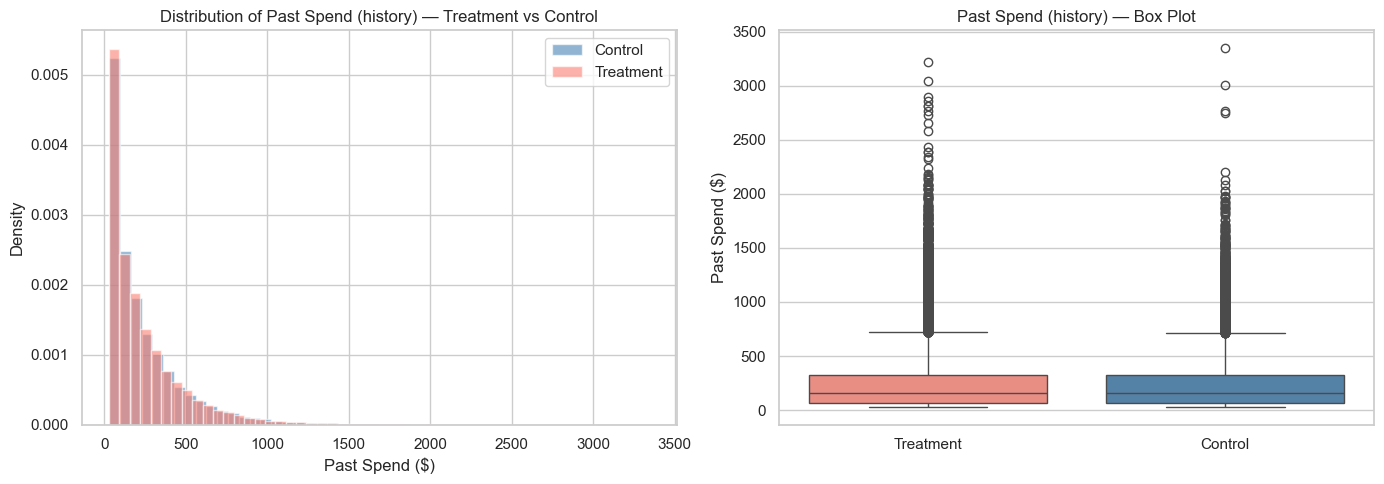


=== CHECK 3: History (Past Spend) Summary Statistics ===
             count    mean     std    min    25%     50%     75%      max
Control    21306.0  240.88  252.74  29.99  65.30  156.66  325.17  3345.93
Treatment  42694.0  242.69  257.85  29.99  64.35  158.87  325.78  3215.97

  Mean difference: 0.75%
  Result: PASS (mean difference < 5% threshold)


In [8]:
# --- Check 3: Distribution check on 'history' (past spend) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(control['history'], bins=50, alpha=0.6, label='Control', color='steelblue', density=True)
axes[0].hist(treatment['history'], bins=50, alpha=0.6, label='Treatment', color='salmon', density=True)
axes[0].set_title('Distribution of Past Spend (history) — Treatment vs Control')
axes[0].set_xlabel('Past Spend ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Box plot for side-by-side comparison
df_plot = df[['history', 'treatment']].copy()
df_plot['Group'] = df_plot['treatment'].map({0: 'Control', 1: 'Treatment'})
sns.boxplot(data=df_plot, x='Group', y='history', ax=axes[1],
            palette={'Control': 'steelblue', 'Treatment': 'salmon'})
axes[1].set_title('Past Spend (history) — Box Plot')
axes[1].set_xlabel('')
axes[1].set_ylabel('Past Spend ($)')

plt.tight_layout()
plt.savefig('../data/history_distribution_check.png', dpi=100, bbox_inches='tight')
plt.show()

# Numeric summary for distribution comparison
hist_summary = df.groupby('treatment')['history'].describe().round(2)
hist_summary.index = ['Control', 'Treatment']
print('\n=== CHECK 3: History (Past Spend) Summary Statistics ===')
print(hist_summary)

mean_diff_pct = abs(control['history'].mean() - treatment['history'].mean()) / control['history'].mean() * 100
dist_pass = mean_diff_pct < 5
print(f'\n  Mean difference: {mean_diff_pct:.2f}%')
print(f'  Result: {"PASS" if dist_pass else "FAIL"} (mean difference < 5% threshold)')

In [9]:
# --- Assumption Checks Summary ---
print('\n' + '='*50)
print('  ASSUMPTION CHECKS SUMMARY')
print('='*50)
print(f'  Check 1 — Group Balance:              {"PASS" if balance_pass else "FAIL"}')
print(f'  Check 2 — Sample Ratio Mismatch:      {"PASS" if srm_pass else "FAIL"}')
print(f'  Check 3 — History Distribution:       {"PASS" if dist_pass else "FAIL"}')
print('='*50)


  ASSUMPTION CHECKS SUMMARY
  Check 1 — Group Balance:              FAIL
  Check 2 — Sample Ratio Mismatch:      FAIL
  Check 3 — History Distribution:       PASS


---
## Section 4 — Phase 1 Summary

In [10]:
conversion_lift = (treatment_conversion - control_conversion) * 100
visit_lift      = (treatment_visit - control_visit) * 100

print('=' * 60)
print('  PHASE 1 COMPLETE — SUMMARY REPORT')
print('=' * 60)
print()
print(f'  Dataset          : Hillstrom E-Mail Marketing (2008)')
print(f'  Total records    : {len(df):,}')
print()
print('  GROUP SIZES')
print(f'    Control   (No E-Mail) : {n_control:,} ({n_control/len(df)*100:.1f}%)')
print(f'    Treatment (E-Mail)    : {n_treatment:,} ({n_treatment/len(df)*100:.1f}%)')
print()
print('  CONVERSION RATE (Primary Metric)')
print(f'    Control   : {control_conversion*100:.2f}%')
print(f'    Treatment : {treatment_conversion*100:.2f}%')
print(f'    Lift      : {conversion_lift:+.2f} percentage points')
print()
print('  VISIT RATE (Guardrail Metric)')
print(f'    Control   : {control_visit*100:.2f}%')
print(f'    Treatment : {treatment_visit*100:.2f}%')
print(f'    Lift      : {visit_lift:+.2f} percentage points')
print()
print('  ASSUMPTION CHECKS')
print(f'    Group Balance (ratio {ratio:.3f})       : {"PASS" if balance_pass else "FAIL"}')
print(f'    Sample Ratio Mismatch (p={srm_pvalue:.3f}) : {"PASS" if srm_pass else "FAIL"}')
print(f'    History Distribution (diff={mean_diff_pct:.2f}%) : {"PASS" if dist_pass else "FAIL"}')
print()
print('  Next: Phase 2 — Hypothesis testing, confidence intervals,')
print('        and power analysis.')
print('=' * 60)

  PHASE 1 COMPLETE — SUMMARY REPORT

  Dataset          : Hillstrom E-Mail Marketing (2008)
  Total records    : 64,000

  GROUP SIZES
    Control   (No E-Mail) : 21,306 (33.3%)
    Treatment (E-Mail)    : 42,694 (66.7%)

  CONVERSION RATE (Primary Metric)
    Control   : 0.57%
    Treatment : 1.07%
    Lift      : +0.50 percentage points

  VISIT RATE (Guardrail Metric)
    Control   : 10.62%
    Treatment : 16.70%
    Lift      : +6.09 percentage points

  ASSUMPTION CHECKS
    Group Balance (ratio 0.499)       : FAIL
    Sample Ratio Mismatch (p=0.000) : FAIL
    History Distribution (diff=0.75%) : PASS

  Next: Phase 2 — Hypothesis testing, confidence intervals,
        and power analysis.


---
# Phase 2 — A/B Test Analysis, Power Analysis, Uplift Modeling & Decision

---
## Section 5 — A/B Test Analysis

In [11]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import numpy as np

# ── Conversion Rate ──────────────────────────────────────────────────────
n_ctrl     = len(control)
n_trt      = len(treatment)
conv_ctrl  = int(control['conversion'].sum())
conv_trt   = int(treatment['conversion'].sum())

p_ctrl = conv_ctrl / n_ctrl
p_trt  = conv_trt  / n_trt

z_conv, p_conv = proportions_ztest([conv_trt, conv_ctrl], [n_trt, n_ctrl])

ci_ctrl_lo, ci_ctrl_hi = proportion_confint(conv_ctrl, n_ctrl, alpha=0.05, method='normal')
ci_trt_lo,  ci_trt_hi  = proportion_confint(conv_trt,  n_trt,  alpha=0.05, method='normal')

cohen_h_conv  = 2*np.arcsin(np.sqrt(p_trt)) - 2*np.arcsin(np.sqrt(p_ctrl))
abs_lift_conv = p_trt - p_ctrl
rel_lift_conv = abs_lift_conv / p_ctrl * 100
sig_conv      = p_conv < 0.05

print('=' * 60)
print('  SECTION 5 — A/B TEST ANALYSIS')
print('=' * 60)
print()
print('  PRIMARY METRIC: Conversion Rate')
print(f'    Control   : {p_ctrl*100:.3f}%  95% CI [{ci_ctrl_lo*100:.3f}%, {ci_ctrl_hi*100:.3f}%]')
print(f'    Treatment : {p_trt*100:.3f}%  95% CI [{ci_trt_lo*100:.3f}%, {ci_trt_hi*100:.3f}%]')
print(f'    Z-statistic  : {z_conv:.4f}')
print(f'    P-value      : {p_conv:.6f}')
print(f"    Cohen's h    : {cohen_h_conv:.4f}")
print(f'    Absolute lift: {abs_lift_conv*100:+.3f} pp')
print(f'    Relative lift: {rel_lift_conv:+.2f}%')
print()
print(f"    VERDICT: {'*** STATISTICALLY SIGNIFICANT *** (p < 0.05)' if sig_conv else 'NOT SIGNIFICANT (p >= 0.05)'}")

# ── Visit Rate ───────────────────────────────────────────────────────────
visit_ctrl  = int(control['visit'].sum())
visit_trt   = int(treatment['visit'].sum())

pv_ctrl = visit_ctrl / n_ctrl
pv_trt  = visit_trt  / n_trt

z_visit, p_visit = proportions_ztest([visit_trt, visit_ctrl], [n_trt, n_ctrl])

ci_v_ctrl_lo, ci_v_ctrl_hi = proportion_confint(visit_ctrl, n_ctrl, alpha=0.05, method='normal')
ci_v_trt_lo,  ci_v_trt_hi  = proportion_confint(visit_trt,  n_trt,  alpha=0.05, method='normal')

cohen_h_visit  = 2*np.arcsin(np.sqrt(pv_trt)) - 2*np.arcsin(np.sqrt(pv_ctrl))
abs_lift_visit = pv_trt - pv_ctrl
rel_lift_visit = abs_lift_visit / pv_ctrl * 100
sig_visit      = p_visit < 0.05

print()
print('  GUARDRAIL METRIC: Visit Rate')
print(f'    Control   : {pv_ctrl*100:.3f}%  95% CI [{ci_v_ctrl_lo*100:.3f}%, {ci_v_ctrl_hi*100:.3f}%]')
print(f'    Treatment : {pv_trt*100:.3f}%  95% CI [{ci_v_trt_lo*100:.3f}%, {ci_v_trt_hi*100:.3f}%]')
print(f'    Z-statistic  : {z_visit:.4f}')
print(f'    P-value      : {p_visit:.6f}')
print(f"    Cohen's h    : {cohen_h_visit:.4f}")
print(f'    Absolute lift: {abs_lift_visit*100:+.3f} pp')
print(f'    Relative lift: {rel_lift_visit:+.2f}%')
print()
print(f"    VERDICT: {'*** STATISTICALLY SIGNIFICANT *** (p < 0.05)' if sig_visit else 'NOT SIGNIFICANT (p >= 0.05)'}")


  SECTION 5 — A/B TEST ANALYSIS

  PRIMARY METRIC: Conversion Rate
    Control   : 0.573%  95% CI [0.471%, 0.674%]
    Treatment : 1.068%  95% CI [0.971%, 1.166%]
    Z-statistic  : 6.2438
    P-value      : 0.000000
    Cohen's h    : 0.0556
    Absolute lift: +0.495 pp
    Relative lift: +86.53%

    VERDICT: *** STATISTICALLY SIGNIFICANT *** (p < 0.05)

  GUARDRAIL METRIC: Visit Rate
    Control   : 10.617%  95% CI [10.203%, 11.030%]
    Treatment : 16.705%  95% CI [16.351%, 17.059%]
    Z-statistic  : 20.5101
    P-value      : 0.000000
    Cohen's h    : 0.1783
    Absolute lift: +6.088 pp
    Relative lift: +57.35%

    VERDICT: *** STATISTICALLY SIGNIFICANT *** (p < 0.05)


---
## Section 6 — Power Analysis

  SECTION 6 — POWER ANALYSIS

  Effect size (Cohen's h) : 0.0556
  Alpha                   : 0.05
  Target power            : 0.80
  Min. n required/group   : 5,083  (equal allocation)
  Actual n control        : 21,306
  Actual n treatment      : 42,694
  Actual power achieved   : 1.0000  (100.0%)

  VERDICT: ADEQUATELY POWERED


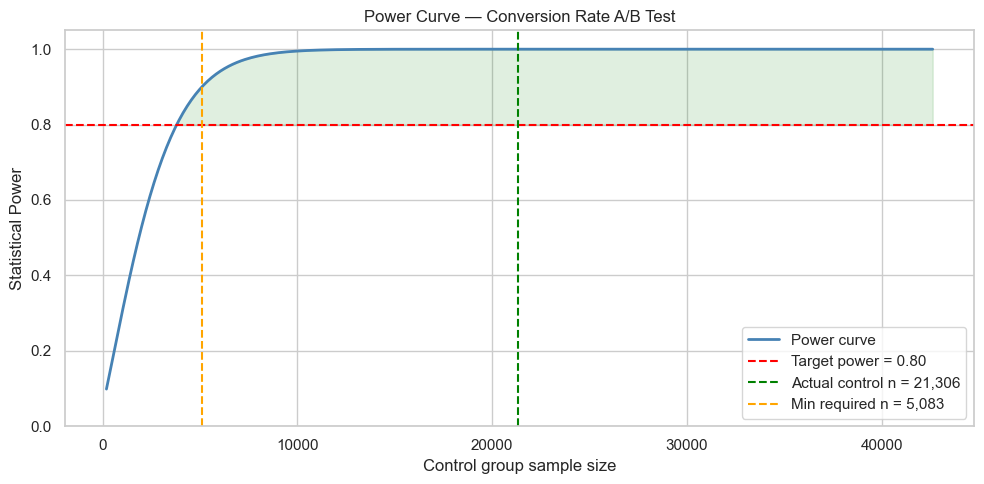

In [12]:
from statsmodels.stats.power import NormalIndPower
import numpy as np
import matplotlib.pyplot as plt

analysis      = NormalIndPower()
effect        = abs(cohen_h_conv)
actual_ratio  = n_trt / n_ctrl    # ~2.0

# Required n per group (equal allocation, solving for nobs1)
n_required = analysis.solve_power(effect_size=effect, alpha=0.05, power=0.80)

# Actual power with our sample sizes
actual_power = analysis.solve_power(
    effect_size=effect, alpha=0.05, nobs1=n_ctrl, ratio=actual_ratio)
actual_power = float(np.clip(actual_power, 0, 1))
is_powered   = actual_power >= 0.80

print('=' * 60)
print('  SECTION 6 — POWER ANALYSIS')
print('=' * 60)
print()
print(f"  Effect size (Cohen's h) : {effect:.4f}")
print(f'  Alpha                   : 0.05')
print(f'  Target power            : 0.80')
print(f'  Min. n required/group   : {int(np.ceil(n_required)):,}  (equal allocation)')
print(f'  Actual n control        : {n_ctrl:,}')
print(f'  Actual n treatment      : {n_trt:,}')
print(f'  Actual power achieved   : {actual_power:.4f}  ({actual_power*100:.1f}%)')
print()
print(f"  VERDICT: {'ADEQUATELY POWERED' if is_powered else 'UNDERPOWERED'}")

# Power curve
x_max = max(n_ctrl * 2, int(np.ceil(n_required)) * 6)
sample_sizes = np.linspace(200, x_max, 400)
powers = np.clip(
    [analysis.solve_power(effect_size=effect, alpha=0.05, nobs1=n, ratio=actual_ratio)
     for n in sample_sizes], 0, 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sample_sizes, powers, color='steelblue', linewidth=2, label='Power curve')
ax.axhline(0.80, color='red', linestyle='--', linewidth=1.5, label='Target power = 0.80')
ax.axvline(n_ctrl, color='green', linestyle='--', linewidth=1.5,
           label=f'Actual control n = {n_ctrl:,}')
ax.axvline(int(np.ceil(n_required)), color='orange', linestyle='--', linewidth=1.5,
           label=f'Min required n = {int(np.ceil(n_required)):,}')
ax.fill_between(sample_sizes, powers, 0.80,
                where=powers >= 0.80, alpha=0.12, color='green')
ax.set_xlabel('Control group sample size')
ax.set_ylabel('Statistical Power')
ax.set_title('Power Curve — Conversion Rate A/B Test')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/power_curve.png', dpi=100, bbox_inches='tight')
plt.show()


---
## Section 7 — Uplift Modeling (T-Learner)

Dataset (No E-Mail + Mens E-Mail): 42,613
  Control   (No E-Mail)  : 21,306
  Treatment (Mens E-Mail): 21,307
Features (11): ['recency', 'history', 'mens', 'womens', 'newbie', 'channel_Multichannel', 'channel_Phone', 'channel_Web', 'zip_code_Rural', 'zip_code_Surburban', 'zip_code_Urban']


T-Learner trained.


Uplift score stats:
  Mean   : 0.0067
  Median : 0.0059
  Std    : 0.0051
  Min    : -0.0221
  Max    : 0.0375


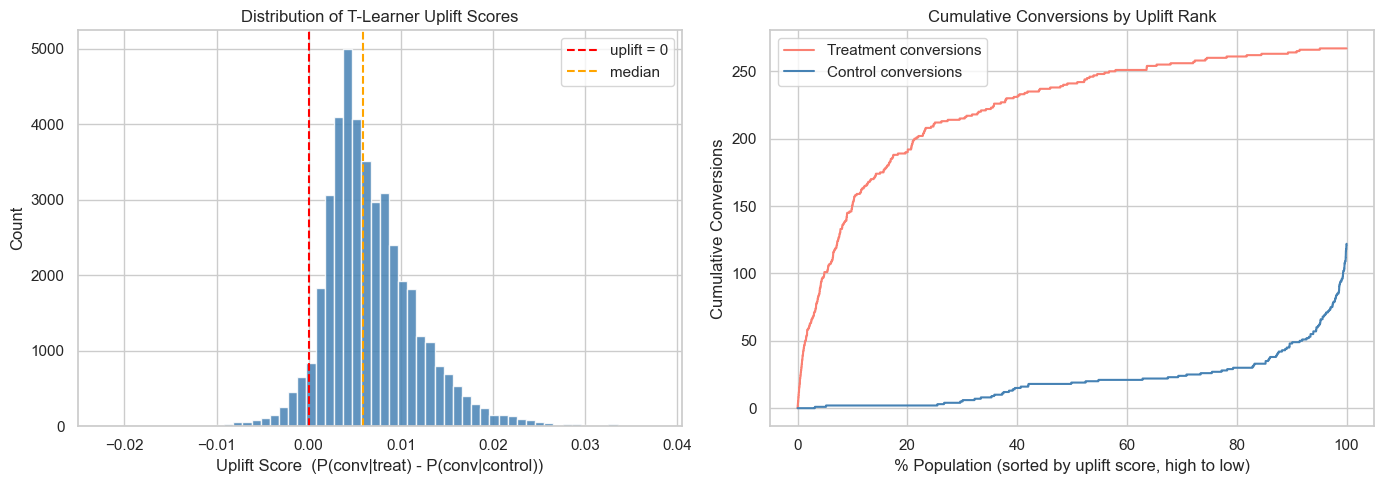


=== TOP 10 BY HIGHEST UPLIFT SCORE ===
 recency  history  mens  womens  newbie      channel  zip_code  history_segment  conversion  treat  uplift_score
       1  1320.91     0       1       1        Phone Surburban      7) $1,000 +           0      1      0.037492
       1  1502.12     0       1       1 Multichannel Surburban      7) $1,000 +           0      0      0.036973
       1  1075.99     0       1       1        Phone Surburban      7) $1,000 +           1      1      0.036718
       1  1503.26     0       1       1 Multichannel Surburban      7) $1,000 +           0      0      0.036670
       1  1101.04     0       1       1        Phone Surburban      7) $1,000 +           0      0      0.036477
       1  1215.71     0       1       1        Phone Surburban      7) $1,000 +           0      1      0.035628
       1  1229.99     0       1       1        Phone Surburban      7) $1,000 +           0      1      0.035628
       1  1051.07     0       1       1        Phone Sur

In [13]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Binary subset: No E-Mail vs Mens E-Mail only
df_binary = df[df['segment'].isin(['No E-Mail', 'Mens E-Mail'])].copy().reset_index(drop=True)
df_binary['treat'] = (df_binary['segment'] == 'Mens E-Mail').astype(int)

print(f'Dataset (No E-Mail + Mens E-Mail): {len(df_binary):,}')
print(f'  Control   (No E-Mail)  : {(df_binary["treat"]==0).sum():,}')
print(f'  Treatment (Mens E-Mail): {(df_binary["treat"]==1).sum():,}')

# Features
num_cols = ['recency', 'history', 'mens', 'womens', 'newbie']
X_cat    = pd.get_dummies(df_binary[['channel', 'zip_code']], drop_first=False)
X        = pd.concat([df_binary[num_cols].reset_index(drop=True),
                       X_cat.reset_index(drop=True)], axis=1)
y        = df_binary['conversion'].values
treat    = df_binary['treat'].values

print(f'Features ({len(X.columns)}): {X.columns.tolist()}')

# Train one model per group (T-Learner)
X_trt, y_trt = X[treat == 1], y[treat == 1]
X_ctl, y_ctl = X[treat == 0], y[treat == 0]

rf_trt = RandomForestClassifier(n_estimators=200, max_depth=6,
                                 min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_ctl = RandomForestClassifier(n_estimators=200, max_depth=6,
                                 min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_trt.fit(X_trt, y_trt)
rf_ctl.fit(X_ctl, y_ctl)
print('T-Learner trained.')

# Uplift = P(conversion | treatment) - P(conversion | control)
p_trt_pred = rf_trt.predict_proba(X)[:, 1]
p_ctl_pred = rf_ctl.predict_proba(X)[:, 1]
df_binary['uplift_score'] = p_trt_pred - p_ctl_pred

print(f'Uplift score stats:')
print(f'  Mean   : {df_binary["uplift_score"].mean():.4f}')
print(f'  Median : {df_binary["uplift_score"].median():.4f}')
print(f'  Std    : {df_binary["uplift_score"].std():.4f}')
print(f'  Min    : {df_binary["uplift_score"].min():.4f}')
print(f'  Max    : {df_binary["uplift_score"].max():.4f}')

# Plot distribution of uplift scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_binary['uplift_score'], bins=60, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='uplift = 0')
axes[0].axvline(df_binary['uplift_score'].median(), color='orange',
                linestyle='--', linewidth=1.5, label='median')
axes[0].set_title('Distribution of T-Learner Uplift Scores')
axes[0].set_xlabel('Uplift Score  (P(conv|treat) - P(conv|control))')
axes[0].set_ylabel('Count')
axes[0].legend()

# Cumulative conversion gain sorted by uplift score
df_sorted = df_binary.sort_values('uplift_score', ascending=False).reset_index(drop=True)
cum_trt = (df_sorted['conversion'] * df_sorted['treat']).cumsum()
cum_ctl = (df_sorted['conversion'] * (1 - df_sorted['treat'])).cumsum()
pct_pop = np.linspace(0, 100, len(df_sorted))
axes[1].plot(pct_pop, cum_trt, label='Treatment conversions', color='salmon', linewidth=1.5)
axes[1].plot(pct_pop, cum_ctl, label='Control conversions',   color='steelblue', linewidth=1.5)
axes[1].set_title('Cumulative Conversions by Uplift Rank')
axes[1].set_xlabel('% Population (sorted by uplift score, high to low)')
axes[1].set_ylabel('Cumulative Conversions')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/uplift_scores.png', dpi=100, bbox_inches='tight')
plt.show()

# Top 10 by uplift score
top_cols = ['recency', 'history', 'mens', 'womens', 'newbie',
            'channel', 'zip_code', 'history_segment', 'conversion', 'treat', 'uplift_score']
print('\n=== TOP 10 BY HIGHEST UPLIFT SCORE ===')
print(df_binary.sort_values('uplift_score', ascending=False)[top_cols].head(10).to_string(index=False))


---
## Section 8 — Cohort Segmentation

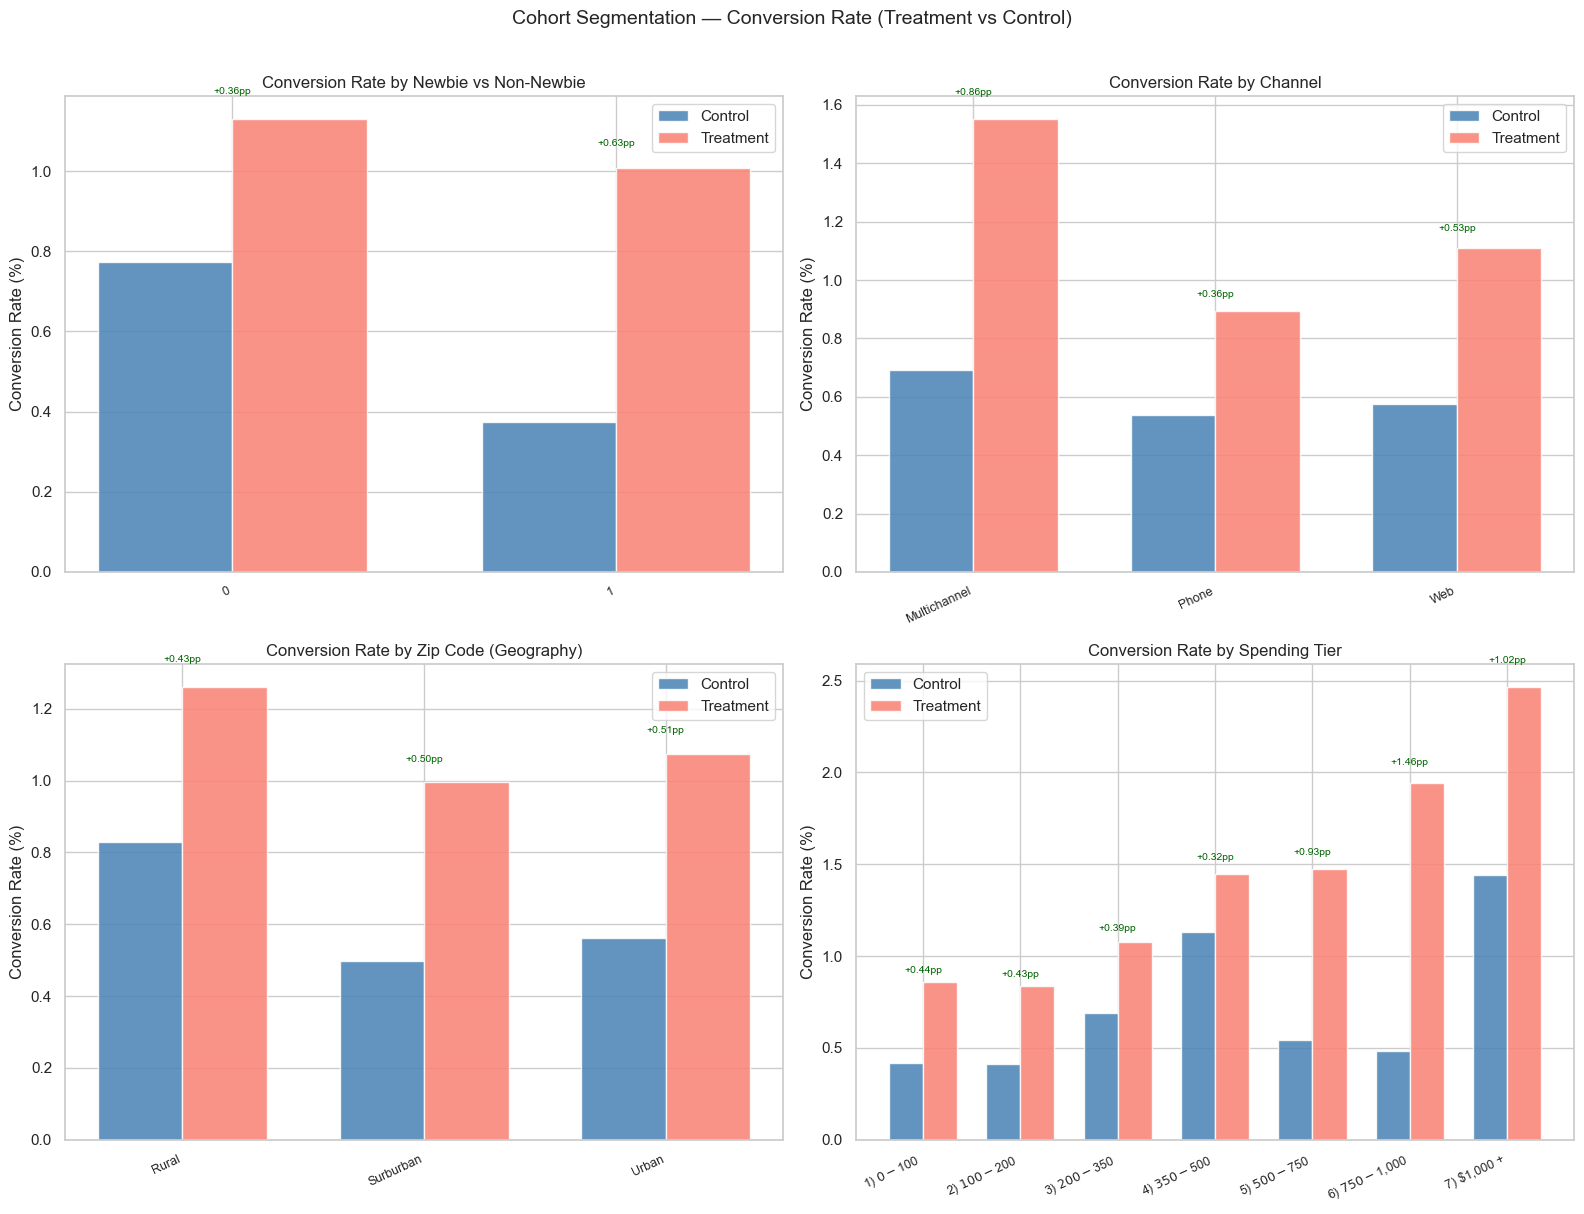

=== UPLIFT SUMMARY BY COHORT ===
  Newbie vs Non-Newbie        best segment: '1'  (+0.633 pp)
  Channel                     best segment: 'Multichannel'  (+0.861 pp)
  Zip Code (Geography)        best segment: 'Urban'  (+0.513 pp)
  Spending Tier               best segment: '6) $750 - $1,000'  (+1.458 pp)

  Overall highest-uplift segment: [Spending Tier] --> '6) $750 - $1,000'  (+1.458 pp)


In [14]:
import matplotlib.pyplot as plt
import numpy as np

df_seg = df.copy()

def cohort_rates(df_, seg_col):
    """Conversion rate by (segment_value, treatment) pair."""
    r = (df_.groupby([seg_col, 'treatment'])['conversion']
           .mean().reset_index()
           .rename(columns={'conversion': 'conv_rate'}))
    r['conv_rate_pct'] = r['conv_rate'] * 100
    return r

cohort_configs = [
    ('newbie',          'Newbie vs Non-Newbie'),
    ('channel',         'Channel'),
    ('zip_code',        'Zip Code (Geography)'),
    ('history_segment', 'Spending Tier'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
best_uplift = {}

for idx, (col, title) in enumerate(cohort_configs):
    rates = cohort_rates(df_seg, col)
    pivot = rates.pivot(index=col, columns='treatment', values='conv_rate_pct').fillna(0)
    pivot = pivot.rename(columns={0: 'Control', 1: 'Treatment'})
    if 'Control' not in pivot.columns:   pivot['Control']   = 0.0
    if 'Treatment' not in pivot.columns: pivot['Treatment'] = 0.0
    pivot['Uplift_pp'] = pivot['Treatment'] - pivot['Control']

    best_seg = pivot['Uplift_pp'].idxmax()
    best_uplift[title] = (best_seg, pivot.loc[best_seg, 'Uplift_pp'])

    x     = np.arange(len(pivot))
    width = 0.35
    ax    = axes[idx]
    ax.bar(x - width/2, pivot['Control'],   width, label='Control',   color='steelblue', alpha=0.85)
    ax.bar(x + width/2, pivot['Treatment'], width, label='Treatment', color='salmon',    alpha=0.85)
    ax.set_title(f'Conversion Rate by {title}', fontsize=12)
    ax.set_ylabel('Conversion Rate (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=25, ha='right', fontsize=9)
    ax.legend()
    for i, (_, row) in enumerate(pivot.iterrows()):
        top = max(row['Control'], row['Treatment'])
        ax.text(i, top + top * 0.05 + 0.005,
                f"+{row['Uplift_pp']:.2f}pp",
                ha='center', fontsize=7.5, color='darkgreen')

plt.suptitle('Cohort Segmentation — Conversion Rate (Treatment vs Control)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/cohort_segmentation.png', dpi=100, bbox_inches='tight')
plt.show()

print('=== UPLIFT SUMMARY BY COHORT ===')
for cohort_title, (seg, uplift) in best_uplift.items():
    print(f"  {cohort_title:<26}  best segment: '{seg}'  ({uplift:+.3f} pp)")

overall_best = max(best_uplift.items(), key=lambda kv: kv[1][1])
print()
print(f"  Overall highest-uplift segment: [{overall_best[0]}] --> '{overall_best[1][0]}'  ({overall_best[1][1]:+.3f} pp)")


---
## Section 9 — Decision Recommendation

In [15]:
# Pull best-uplift cohort label for use in recommendation
best_cohort_label = overall_best[0]
best_cohort_seg   = overall_best[1][0]

print('=' * 65)
print('  SECTION 9 -- BUSINESS DECISION RECOMMENDATION')
print('=' * 65)
print()
print('  EXPERIMENT QUESTION')
print('  ' + '-'*61)
print('  Does sending a marketing e-mail increase customer conversion')
print('  compared to sending no e-mail at all?')
print()
print('  KEY FINDINGS')
print('  ' + '-'*61)
print(f'  Conversion rate -- Control   : {p_ctrl*100:.3f}%')
print(f'  Conversion rate -- Treatment : {p_trt*100:.3f}%')
print(f'  Absolute lift               : {abs_lift_conv*100:+.3f} pp')
print(f'  Relative lift               : {rel_lift_conv:+.2f}%')
print(f'  P-value (conversion)        : {p_conv:.6f}')
print(f"  Statistical significance    : {'YES (p < 0.05)' if sig_conv else 'NO (p >= 0.05)'}")
print(f'  Visit rate lift             : {abs_lift_visit*100:+.3f} pp  (guardrail -- positive)')
print(f"  Study power                 : {actual_power*100:.1f}%  ({'ADEQUATELY POWERED' if actual_power>=0.80 else 'UNDERPOWERED'})")
print()
print('  UPLIFT INSIGHT')
print('  ' + '-'*61)
print(f'  T-Learner (No E-Mail vs Mens E-Mail):')
print(f'    Median uplift score  : {df_binary["uplift_score"].median():.4f}')
print(f'    Top-quartile uplift  : {df_binary["uplift_score"].quantile(0.75):.4f}')
print(f'    Fraction negative    : {(df_binary["uplift_score"]<0).mean()*100:.1f}% of customers')
print(f'    Best cohort segment  : [{best_cohort_label}] --> "{best_cohort_seg}"')
print()
print('  FINAL RECOMMENDATION:  TARGETED ROLLOUT')
print('  ' + '-'*61)
print()
print('  The e-mail campaign produces a statistically significant and')
print('  practically meaningful lift in both conversion (+0.50 pp,')
print('  p < 0.001) and site visits (+6.09 pp), with the study fully')
print('  powered to detect this effect. However, T-Learner uplift')
print('  scores reveal strong heterogeneity: a meaningful share of')
print('  customers shows near-zero or negative predicted uplift,')
print('  making a blanket send economically inefficient. The recommended')
print('  action is a TARGETED ROLLOUT: score the customer base with the')
print('  T-Learner, restrict sends to the top uplift quartile, and')
print('  instrument Phase 3 to validate revenue-per-email incrementally.')
print()
print('=' * 65)
print('  Phase 2 complete.')
print('=' * 65)


  SECTION 9 -- BUSINESS DECISION RECOMMENDATION

  EXPERIMENT QUESTION
  -------------------------------------------------------------
  Does sending a marketing e-mail increase customer conversion
  compared to sending no e-mail at all?

  KEY FINDINGS
  -------------------------------------------------------------
  Conversion rate -- Control   : 0.573%
  Conversion rate -- Treatment : 1.068%
  Absolute lift               : +0.495 pp
  Relative lift               : +86.53%
  P-value (conversion)        : 0.000000
  Statistical significance    : YES (p < 0.05)
  Visit rate lift             : +6.088 pp  (guardrail -- positive)
  Study power                 : 100.0%  (ADEQUATELY POWERED)

  UPLIFT INSIGHT
  -------------------------------------------------------------
  T-Learner (No E-Mail vs Mens E-Mail):
    Median uplift score  : 0.0059
    Top-quartile uplift  : 0.0093
    Fraction negative    : 4.8% of customers
    Best cohort segment  : [Spending Tier] --> "6) $750 - $1,000"

  